# Part 1 — Initial Project Setup

## 1.1 Download Data


In [6]:
import pandas as pd
import yfinance as yf
import datetime as dt
import matplotlib.pyplot as plt
import numpy as np

FINAL_TICKERS = ["AMH", "AVB", "CPT", "ELS", "EQR", "IRT", "MAA", "SUI", "UDR", "UMH"]

end_date = dt.datetime.now().strftime('%Y-%m-%d')
start_date = (pd.to_datetime(end_date) - pd.DateOffset(365*12)).strftime('%Y-%m-%d')
df = yf.download(FINAL_TICKERS, start=start_date, end=end_date, auto_adjust=True)['Close']


df = df.dropna(axis=1)
df

[*********************100%***********************]  10 of 10 completed


Ticker,AMH,AVB,CPT,ELS,EQR,IRT,MAA,SUI,UDR,UMH
Date,,,,,,,,,,
2014-07-28,15.052719,100.717758,46.380127,16.618071,36.666237,4.999763,48.381027,35.982559,18.898890,5.140668
2014-07-29,14.963073,100.342270,46.204403,16.577459,36.526600,5.046154,48.329170,35.799137,18.885845,5.161649
2014-07-30,15.044571,101.240791,46.392685,16.562683,37.079529,5.077079,48.562553,35.928215,19.120693,5.219349
2014-07-31,14.848974,99.296204,45.413612,16.352242,36.107723,5.077079,45.327663,35.751606,18.970648,5.198369
2014-08-01,14.645227,99.698517,45.488941,16.237789,35.817303,4.999763,45.353580,35.697250,18.859751,5.145914
...,...,...,...,...,...,...,...,...,...,...
2026-07-17,34.070000,192.529999,112.970001,65.750000,69.000000,16.620001,132.960007,121.459999,39.759998,15.690000
2026-07-20,33.700001,191.839996,112.860001,65.260002,68.800003,16.500000,133.710007,120.199997,39.740002,15.600000
2026-07-21,33.320000,190.649994,112.089996,64.900002,68.290001,16.469999,132.240005,119.040001,39.570000,15.490000


## 1.2 Base Mean-Reversion Strategy


--- Strategy ---
Total return: 179.95%
Sharpe ratio: 1.28
Max drawdown: -8.56%
--- Benchmark ---
Total return: 185.15%
Sharpe ratio: 0.51
Max drawdown: -39.51%


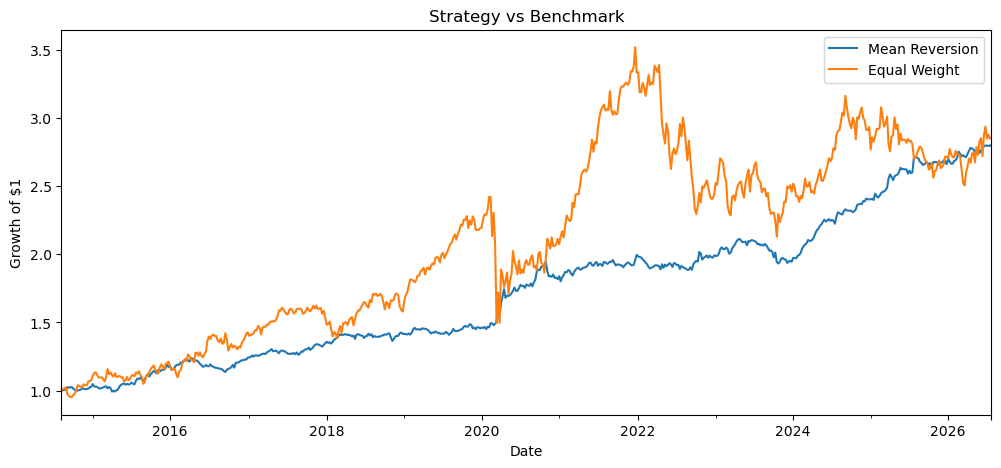

In [7]:
from backtest import run_backtest, run_benchmark, print_stats

end = df.index.max()
start = df.index.min()

strategy = run_backtest(df, start_date=start, end_date=end, cost_bps=0)
benchmark = run_benchmark(df, start_date=start, end_date=end)

print("--- Strategy ---")
print_stats(strategy["stats"])

print("--- Benchmark ---")
print_stats(benchmark["stats"])


equity = strategy["equity"]
cluster_equity = benchmark["equity"]

plt.figure(figsize=(12, 5))
(equity / equity.iloc[0]).plot(label="Mean Reversion")
(cluster_equity / cluster_equity.iloc[0]).plot(label="Equal Weight")
plt.legend()
plt.ylabel("Growth of $1")
plt.title("Strategy vs Benchmark")
plt.show()

## 1.3 Prepare Forward Returns

The strategy predicts long/short positions for each stock for each week. Based on the outcome of the NEXT week (after the prediction), we label each position as successful (1) or unsuccessful (0). 
- For a stock in a long position, success = price goes up the next week
- For a stock in a short position, success = price goes down the next week


In [8]:
strategy['dollar_positions'].head(10)

Ticker,AMH,AVB,CPT,ELS,EQR,IRT,MAA,SUI,UDR,UMH
Date,,,,,,,,,,
2014-08-08,3185.984262,204.419857,323.687385,829.688172,-514.361220,240.407213,215.813110,-1329.620135,-431.432166,-2724.586480
2014-08-15,1912.058139,253.854318,-656.883678,-1088.582647,-223.827285,-2860.996843,411.145656,-169.709548,571.631449,1851.310438
2014-08-22,-1762.041510,-768.711313,1087.152309,540.844084,-22.728599,-1751.187110,129.560355,2873.430769,369.012483,-695.331469
2014-08-29,2374.741373,157.294705,-1061.600738,-1639.954371,526.528939,1661.440782,-699.899154,279.994201,-443.107013,-1155.438724
2014-09-05,-1484.378927,-671.531066,-196.482068,-411.284737,-760.667467,3464.159106,-203.365786,-483.341114,-788.948835,1535.840894
2014-09-12,-1592.596745,1222.763922,458.280732,160.102700,1145.342674,-2950.833953,740.831973,386.085347,886.592651,-456.569302
2014-09-19,607.211741,-813.415137,1585.140282,1425.336377,-536.356096,-1205.013040,737.019414,-2445.215727,602.433015,42.859171
2014-09-26,541.608715,911.253546,-1029.737264,-2271.510065,-322.741441,1552.752281,31.112692,-1376.011230,292.074925,1671.197840
2014-10-03,570.126344,-1115.823933,-90.047514,-179.229363,-2094.516192,2034.384316,-158.921870,1817.426664,578.062676,-1361.461128


In [9]:
from backtest import prepare_weekly_data
_, weekly_simple_returns = prepare_weekly_data(df)
weekly_simple_returns.head(10)

Ticker,AMH,AVB,CPT,ELS,EQR,IRT,MAA,SUI,UDR,UMH
Date,,,,,,,,,,
2014-08-08,-0.018364,0.007533,0.006484,0.002046,0.013878,0.007217,0.007433,0.021123,0.013144,0.033639
2014-08-15,-0.000567,0.007743,0.012337,0.014522,0.010150,0.023541,0.006952,0.009877,0.006145,-0.000264
2014-08-22,0.026092,0.017687,0.002166,0.006710,0.011419,0.026000,0.010145,-0.012549,0.008144,0.017068
2014-08-29,-0.011609,0.003060,0.011215,0.015108,0.000602,-0.006914,0.008788,0.002242,0.007069,0.011846
2014-09-05,0.015660,0.011421,0.008952,0.010068,0.011885,-0.009872,0.008988,0.010442,0.012032,0.000000
2014-09-12,-0.025925,-0.069870,-0.058138,-0.053521,-0.068689,-0.003988,-0.062491,-0.057022,-0.064729,-0.043902
2014-09-19,-0.017007,0.000207,-0.028684,-0.026785,-0.003173,0.005005,-0.018565,0.020353,-0.016949,-0.010204
2014-09-26,-0.016148,-0.019308,-0.002600,0.008239,-0.008718,-0.024768,-0.011767,0.000411,-0.014009,-0.025773
2014-10-03,-0.001758,0.011770,0.003517,0.004232,0.019707,-0.013361,0.004069,-0.011650,-0.001822,0.013756


In [10]:
_, weekly_simple_returns = prepare_weekly_data(df)

forward_returns = weekly_simple_returns.shift(-1)
forward_returns


Ticker,AMH,AVB,CPT,ELS,EQR,IRT,MAA,SUI,UDR,UMH
Date,,,,,,,,,,
2014-08-08,-0.000567,0.007743,0.012337,0.014522,0.010150,0.023541,0.006952,0.009877,0.006145,-0.000264
2014-08-15,0.026092,0.017687,0.002166,0.006710,0.011419,0.026000,0.010145,-0.012549,0.008144,0.017068
2014-08-22,-0.011609,0.003060,0.011215,0.015108,0.000602,-0.006914,0.008788,0.002242,0.007069,0.011846
2014-08-29,0.015660,0.011421,0.008952,0.010068,0.011885,-0.009872,0.008988,0.010442,0.012032,0.000000
2014-09-05,-0.025925,-0.069870,-0.058138,-0.053521,-0.068689,-0.003988,-0.062491,-0.057022,-0.064729,-0.043902
...,...,...,...,...,...,...,...,...,...,...
2026-06-26,-0.000293,0.029712,0.017319,0.031449,0.031813,0.024837,0.010446,0.029137,0.027764,0.004531
2026-07-03,-0.023768,-0.010930,-0.036588,-0.041962,-0.016325,-0.034045,-0.048808,-0.038421,-0.033098,-0.015464
2026-07-10,0.024046,0.003597,0.000089,0.035922,0.004513,-0.007168,-0.005550,0.021703,0.004345,0.026832


## 1.4 Engineer Features
ChatGPT suggested these 9 features:
- `side`: Whether the proposed position is long or short.
- `abs_base_weight`: How large the position is compared with the £10,000 portfolio.
- `residual_zscore`: How unusual the stock’s movement is compared with the other stocks that week.
- `residual_lag1`: The stock’s residual from the previous week.
- `residual_4w_sum`: The total residual over the last four weeks.
- `residual_vol_4w`: How much the residual moved around during the last four weeks.
- `stock_vol_4w`: How much the stock’s weekly returns moved around during the last four weeks.
- `cluster_return`: How the whole group of REIT stocks performed this week.
- `cluster_vol_4w`: How volatile the whole group has been over the last four weeks.

I will start with these features for now and make necessary edits later.


In [11]:
I = 10_000

from backtest import build_mean_reversion_positions

# weekly data (same as backtest)
weekly_log_returns, weekly_simple_returns = prepare_weekly_data(df)
forward_returns = weekly_simple_returns.shift(-1)

# Development observations use a fixed tau
DEVELOPMENT_TAU = 0.01
positions = build_mean_reversion_positions(
    weekly_log_returns=weekly_log_returns,
    gross_exposure=I,
    tau=DEVELOPMENT_TAU,
)

trade_result = positions * forward_returns
label = (trade_result > 0).astype(int)

# residuals for each stock
cluster_return = weekly_log_returns.mean(axis=1) # mean cluster return
residuals = weekly_log_returns.sub(cluster_return, axis=0)

# residual z-score within each week (across tickers)
# z-score is how many stds away from mean, (x - mean) / std
residual_zscore = residuals.sub(residuals.mean(axis=1), axis=0).div(
    residuals.std(axis=1), axis=0
)

# align everything to positions' index
common_idx = positions.index.intersection(weekly_log_returns.index).intersection(
    forward_returns.dropna(how="all").index
)

positions = positions.loc[common_idx]
residuals = residuals.loc[common_idx]
residual_zscore = residual_zscore.loc[common_idx]
weekly_simple_returns = weekly_simple_returns.loc[common_idx]
weekly_log_returns = weekly_log_returns.loc[common_idx]
cluster_return = cluster_return.loc[common_idx]
forward_returns = forward_returns.loc[common_idx]
label = label.loc[common_idx]

# feature calculation, all are pretty self explanatory
side = np.sign(positions)
abs_base_weight = positions.abs() / I

residual_lag1 = residuals.shift(1)
residual_4w_sum = residuals.rolling(4).sum()
residual_vol_4w = residuals.rolling(4).std()
stock_vol_4w = weekly_simple_returns.rolling(4).std()
cluster_vol_4w = cluster_return.rolling(4).std()

# Current residual relative to the stock's previous 26 weeks
residual_history = residuals.shift(1)

residual_mean_26w = residual_history.rolling(
    window=26,
    min_periods=26,
).mean()

residual_std_26w = residual_history.rolling(
    window=26,
    min_periods=26,
).std()

residual_ts_zscore_26w = (
    residuals - residual_mean_26w
).div(
    residual_std_26w.replace(0, np.nan)
)

# Lag-1 autocorrelation calculated using the previous 26 weeks
residual_autocorr_26w = (
    residuals.shift(1)
    .rolling(
        window=26,
        min_periods=26,
    )
    .apply(
        lambda window: window.autocorr(lag=1),
        raw=False,
    )
)

number_of_stocks = weekly_log_returns.shape[1]

# Sum of every stock's return during each week
cluster_return_sum = weekly_log_returns.sum(
    axis=1,
    skipna=False,
)

# For each stock, subtract its return before calculating the peer average
leave_one_out_cluster_returns = (
    weekly_log_returns.rsub(
        cluster_return_sum,
        axis=0,
    )
    / (number_of_stocks - 1)
)

stock_cluster_corr_26w = (
    weekly_log_returns.shift(1)
    .rolling(
        window=26,
        min_periods=26,
    )
    .corr(
        leave_one_out_cluster_returns.shift(1)
    )
)

# Cross-sectional spread of stock residuals during each week
residual_dispersion = residuals.std(axis=1)

# stack into long table: one row = one week and one ticker
features = pd.concat(
    {
        "base_position": positions,
        "side": side,
        "abs_base_weight": abs_base_weight,
        "residual_zscore": residual_zscore,
        "residual_ts_zscore_26w": residual_ts_zscore_26w,
        "residual_autocorr_26w": residual_autocorr_26w,
        "residual_lag1": residual_lag1,
        "residual_4w_sum": residual_4w_sum,
        "residual_vol_4w": residual_vol_4w,
        "stock_vol_4w": stock_vol_4w,
        "stock_cluster_corr_26w": stock_cluster_corr_26w,
        "label": label,
    },
    axis=1,
).stack(level=1)
features.index.names = ["date", "ticker"]
# features = features.reset_index()

# cluster_return / cluster_vol are the same for all tickers on a date
features = features.drop(columns=["cluster_return"], errors="ignore")
features = features.reset_index()
# features["cluster_return"] = features["date"].map(cluster_return)
# features["cluster_vol_4w"] = features["date"].map(cluster_vol_4w)
# features["residual_dispersion"] = features["date"].map(
#     residual_dispersion
# )

# Zero positions are rejected signals, not ML observations
features = features[
    features["base_position"] != 0
].copy()

# drop early rows with NaNs from rolling windows / last week with no forward return
features = features.dropna().reset_index(drop=True)

features


,date,ticker,base_position,side,abs_base_weight,residual_zscore,residual_ts_zscore_26w,residual_autocorr_26w,residual_lag1,residual_4w_sum,residual_vol_4w,stock_vol_4w,stock_cluster_corr_26w,label
0,2015-02-06,EQR,-2780.095243,-1.0,0.278010,1.213554,2.002048,0.058037,-0.009841,0.025295,0.013805,0.023998,0.900719,0
1,2015-02-06,MAA,3996.033226,1.0,0.399603,-2.291969,-3.883687,-0.183430,-0.016584,-0.030985,0.028048,0.044098,0.834904,0
2,2015-02-06,UDR,1003.966774,1.0,0.100397,-0.575836,-1.218313,-0.199821,0.006031,0.022964,0.011522,0.027290,0.859732,1
3,2015-02-06,UMH,-2219.904757,-1.0,0.221990,0.969022,1.454988,-0.287925,0.016948,-0.003550,0.024371,0.007940,0.655166,0
4,2015-02-13,AVB,-5000.000000,-1.0,0.500000,1.250816,1.006862,-0.134872,-0.006729,-0.015718,0.011399,0.019505,0.882055,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2660,2026-07-17,ELS,-1914.217240,-1.0,0.191422,1.665034,1.280357,0.096800,-0.012393,0.007560,0.019051,0.039403,0.731120,0
2661,2026-07-17,IRT,1998.952796,1.0,0.199895,-1.208734,-1.111374,-0.204377,-0.004163,0.003358,0.016359,0.049262,0.886626,0
2662,2026-07-17,MAA,1816.739043,1.0,0.181674,-1.098552,-1.665895,0.058272,-0.019565,-0.041795,0.010427,0.045785,0.951458,0
2663,2026-07-17,SUI,-839.397668,-1.0,0.083940,0.730129,0.674724,-0.048949,-0.008704,-0.022480,0.020142,0.031767,0.692737,1


# Part 2 — Hyperparameter Development

We will train and optimise hyperparameters for 3 models: logistic regression, random forest and xgBoost


## 2.1 Development Data


In [12]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Hyperparameter development window: 2015–2018 only
development_dates = pd.DatetimeIndex(
    np.sort(
        features.loc[
            features["date"].dt.year.between(2015, 2018),
            "date",
        ].unique()
    )
)

training_dates_with_gap = development_dates[
    development_dates.year <= 2017
]
gap_date = training_dates_with_gap[-1]
training_dates = training_dates_with_gap[:-1]

validation_dates = development_dates[
    development_dates.year == 2018
]

training_set = features[features["date"].isin(training_dates)].copy()
validation_set = features[features["date"].isin(validation_dates)].copy()

for name, dataset in [
    ("Training", training_set),
    ("Validation", validation_set),
]:
    print(
        f"{name}:",
        dataset["date"].min().date(),
        "to",
        dataset["date"].max().date(),
        "| weeks:",
        dataset["date"].nunique(),
        "| rows:",
        len(dataset),
        "| profitable:",
        f"{dataset['label'].mean():.3f}",
    )

print("Gap week:", gap_date.date())

X_train, y_train = (
    training_set.drop(columns=["label", "date", "ticker", "base_position"]),
    training_set["label"],
)
X_validation, y_validation = (
    validation_set.drop(columns=["label", "date", "ticker", "base_position"]),
    validation_set["label"],
)


Training: 2015-02-06 to 2017-12-22 | weeks: 143 | rows: 695 | profitable: 0.504
Validation: 2018-01-05 to 2018-12-28 | weeks: 44 | rows: 171 | profitable: 0.503
Gap week: 2017-12-29


## 2.2 Logistic Regression Baseline

For this test, we do not tune any hyperparameters for logistic regression.

In [26]:
# Train the model on the training set
logistic_model = Pipeline([
    ("scaler", StandardScaler()),
    ("classifier", LogisticRegression(
        random_state=2,
        max_iter=1000,
    ))
])

logistic_model.fit(X_train, y_train)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('scaler', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](10,)","['side','abs_base_weight','residual_zscore',...,'residual_vol_4w', 'stock_vol_4w','stock_cluster_corr_26w']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,10
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


In [27]:
# Evaluate on both training and validation data
logistic_train_pred = logistic_model.predict(X_train)
logistic_val_pred = logistic_model.predict(X_validation)

metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
train_scores = [
    accuracy_score(y_train, logistic_train_pred),
    precision_score(y_train, logistic_train_pred),
    recall_score(y_train, logistic_train_pred),
    f1_score(y_train, logistic_train_pred)
]

val_scores = [
    accuracy_score(y_validation, logistic_val_pred),
    precision_score(y_validation, logistic_val_pred),
    recall_score(y_validation, logistic_val_pred),
    f1_score(y_validation, logistic_val_pred)
]

logistic_results_df = pd.DataFrame({
    'Training': train_scores,
    'Validation': val_scores
}, index=metrics)

logistic_results_df

,Training,Validation
Accuracy,0.564029,0.508772
Precision,0.572755,0.515625
Recall,0.528571,0.383721
F1 Score,0.549777,0.440000


## 2.3 Random Forest Tuning

Random Forest will be tuned on the following combination of parameters:
- Number of trees: 100, 500, 1000
- Depth: 2, 4, 6
- Leaf number: 10, 30, 60


,n_estimators,max_depth,min_samples_leaf,train_auc,validation_auc,auc_gap
0,100,10,3,0.999114,0.590150,0.408963
1,100,6,5,0.940207,0.581259,0.358948
2,1000,10,3,0.999735,0.578933,0.420802
3,100,8,5,0.980671,0.577291,0.403379
4,500,10,3,0.999578,0.575923,0.423654
...,...,...,...,...,...,...
85,1000,2,60,0.643031,0.513680,0.129351
86,1000,2,30,0.661449,0.513406,0.148043
87,500,2,10,0.679354,0.512722,0.166632
88,500,2,30,0.663280,0.512585,0.150694


,n_estimators,max_depth,min_samples_leaf,train_auc,validation_auc,auc_gap
0,100,2,3,0.682344,0.539124,0.143219
1,100,2,5,0.681789,0.532011,0.149778
2,100,4,60,0.673168,0.526129,0.147039
3,100,8,60,0.674501,0.525992,0.148509
4,100,10,60,0.674501,0.525992,0.148509
5,100,6,60,0.674501,0.525992,0.148509
6,1000,8,60,0.667876,0.522298,0.145578
7,1000,10,60,0.667876,0.522298,0.145578
8,1000,6,60,0.667876,0.522298,0.145578
9,1000,4,60,0.667586,0.522025,0.145561


best_rf_params: {'n_estimators': 100, 'max_depth': 2, 'min_samples_leaf': 3}
chosen train/val AUC: 0.6823 / 0.5391 | gap: 0.1432
Accuracy: 0.5380116959064327
Precision: 0.5402298850574713
Recall: 0.5465116279069767
F1: 0.5433526011560693
AUC: 0.539124487004104


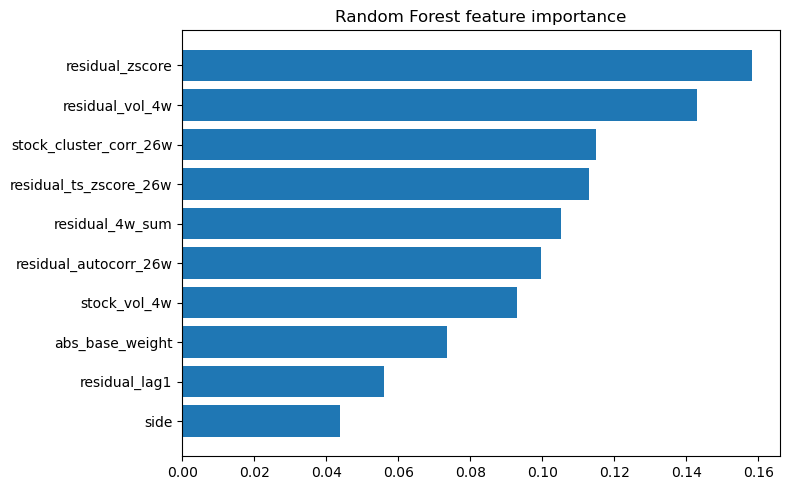

In [47]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

rf_candidates = [
    {
        "n_estimators": estimators,
        "max_depth": depth,
        "min_samples_leaf": leaf,
    }
    for depth in [2, 4, 6, 8, 10]
    for leaf in [3, 5, 8, 10, 30, 60]
    for estimators in [100, 500, 1000]
]

rf_rows = []

for params in rf_candidates:
    candidate = RandomForestClassifier(
        max_features="sqrt",
        random_state=1,
        n_jobs=-1,
        **params,
    )
    candidate.fit(X_train, y_train)

    train_probability = candidate.predict_proba(X_train)[:, 1]
    validation_probability = candidate.predict_proba(X_validation)[:, 1]

    train_auc = roc_auc_score(y_train, train_probability)
    validation_auc = roc_auc_score(y_validation, validation_probability)

    rf_rows.append(
        {
            **params,
            "train_auc": train_auc,
            "validation_auc": validation_auc,
            "auc_gap": train_auc - validation_auc,
        }
    )

rf_results = pd.DataFrame(rf_rows).sort_values(
    "validation_auc",
    ascending=False,
).reset_index(drop=True)

display(rf_results)

# Reject obviously overfit models, then pick the best remaining validation AUC.
acceptable_models = rf_results[rf_results["auc_gap"] <= 0.15].copy()

if acceptable_models.empty:
    raise ValueError(
        "No Random Forest candidates had auc_gap <= 0.15. "
        "Loosen the gap threshold or shrink the search space."
    )

acceptable_models = acceptable_models.sort_values(
    ["validation_auc", "auc_gap"],
    ascending=[False, True],
).reset_index(drop=True)

display(acceptable_models)

best_rf_params = {
    "n_estimators": int(acceptable_models.iloc[0]["n_estimators"]),
    "max_depth": int(acceptable_models.iloc[0]["max_depth"]),
    "min_samples_leaf": int(acceptable_models.iloc[0]["min_samples_leaf"]),
}
print("best_rf_params:", best_rf_params)
print(
    "chosen train/val AUC:",
    round(acceptable_models.iloc[0]["train_auc"], 4),
    "/",
    round(acceptable_models.iloc[0]["validation_auc"], 4),
    "| gap:",
    round(acceptable_models.iloc[0]["auc_gap"], 4),
)

# Fit the winner into `rf` so the importance / ROC cells keep working
rf = RandomForestClassifier(

    max_features="sqrt",
    random_state=1,
    n_jobs=-1,
    **best_rf_params,
)
rf.fit(X_train, y_train)

y_pred = rf.predict(X_validation)
y_prob = rf.predict_proba(X_validation)[:, 1]

print("Accuracy:", accuracy_score(y_validation, y_pred))
print("Precision:", precision_score(y_validation, y_pred))
print("Recall:", recall_score(y_validation, y_pred))
print("F1:", f1_score(y_validation, y_pred))
print("AUC:", roc_auc_score(y_validation, y_prob))

importances = pd.Series(rf.feature_importances_, index=X_train.columns)
sorted_imp = importances.sort_values()
plt.figure(figsize=(8, 5))
plt.barh(sorted_imp.index.astype(str), sorted_imp.values)
plt.title("Random Forest feature importance")
plt.tight_layout()
plt.show()


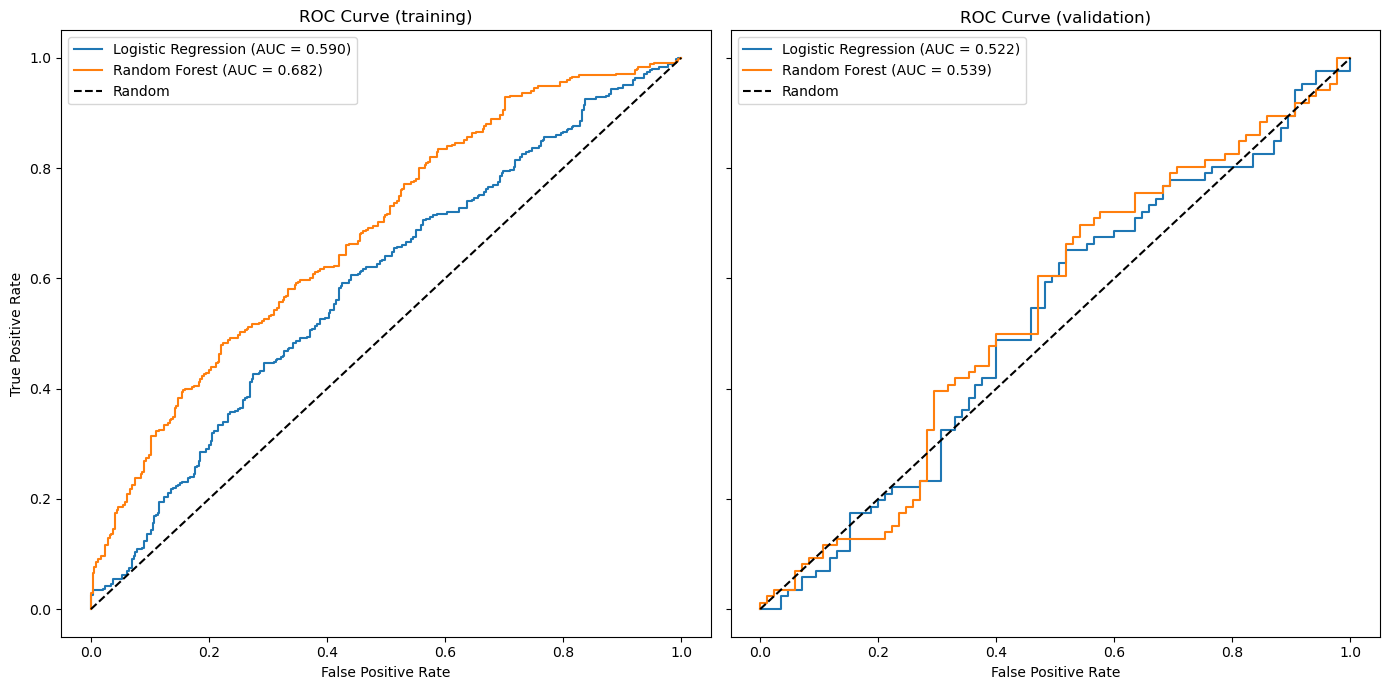

In [40]:
from sklearn.metrics import roc_curve, roc_auc_score

# Probabilities for training and validation sets
lr_prob_val = logistic_model.predict_proba(X_validation)[:, 1]
rf_prob_val = rf.predict_proba(X_validation)[:, 1]
lr_prob_train = logistic_model.predict_proba(X_train)[:, 1]
rf_prob_train = rf.predict_proba(X_train)[:, 1]

# ROC curve for the training set
lr_fpr_train, lr_tpr_train, _ = roc_curve(y_train, lr_prob_train)
rf_fpr_train, rf_tpr_train, _ = roc_curve(y_train, rf_prob_train)

lr_auc_train = roc_auc_score(y_train, lr_prob_train)
rf_auc_train = roc_auc_score(y_train, rf_prob_train)

# ROC curve for the validation set
lr_fpr_val, lr_tpr_val, _ = roc_curve(y_validation, lr_prob_val)
rf_fpr_val, rf_tpr_val, _ = roc_curve(y_validation, rf_prob_val)

lr_auc_val = roc_auc_score(y_validation, lr_prob_val)
rf_auc_val = roc_auc_score(y_validation, rf_prob_val)

fig, axes = plt.subplots(1, 2, figsize=(14, 7), sharey=True)

# Plot ROC for training set (left)
axes[0].plot(lr_fpr_train, lr_tpr_train, label=f"Logistic Regression (AUC = {lr_auc_train:.3f})")
axes[0].plot(rf_fpr_train, rf_tpr_train, label=f"Random Forest (AUC = {rf_auc_train:.3f})")
axes[0].plot([0, 1], [0, 1], "k--", label="Random")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("ROC Curve (training)")
axes[0].legend()

# Plot ROC for validation set (right)
axes[1].plot(lr_fpr_val, lr_tpr_val, label=f"Logistic Regression (AUC = {lr_auc_val:.3f})")
axes[1].plot(rf_fpr_val, rf_tpr_val, label=f"Random Forest (AUC = {rf_auc_val:.3f})")
axes[1].plot([0, 1], [0, 1], "k--", label="Random")
axes[1].set_xlabel("False Positive Rate")
axes[1].set_title("ROC Curve (validation)")
axes[1].legend()

plt.tight_layout()
plt.show()


## 2.4 XGBoost Tuning


In [44]:
from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
)

xgb_candidates = [
    {
        "n_estimators": 100,
        "learning_rate": 0.03,
        "max_depth": 1,
        "min_child_weight": 30,
    },
    {
        "n_estimators": 100,
        "learning_rate": 0.03,
        "max_depth": 2,
        "min_child_weight": 30,
    },
    {
        "n_estimators": 100,
        "learning_rate": 0.03,
        "max_depth": 3,
        "min_child_weight": 30,
    },
    {
        "n_estimators": 100,
        "learning_rate": 0.03,
        "max_depth": 2,
        "min_child_weight": 50,
    },
    {
        "n_estimators": 50,
        "learning_rate": 0.05,
        "max_depth": 2,
        "min_child_weight": 30,
    },
    {
        "n_estimators": 100,
        "learning_rate": 0.01,
        "max_depth": 2,
        "min_child_weight": 30,
    },
]

xgb_rows = []

for params in xgb_candidates:
    candidate = XGBClassifier(
        objective="binary:logistic",
        eval_metric="logloss",
        subsample=0.80,
        colsample_bytree=0.80,
        reg_alpha=0.10,
        reg_lambda=2.00,
        random_state=1,
        n_jobs=-1,
        **params,
    )
    candidate.fit(X_train, y_train)

    validation_probability = candidate.predict_proba(X_validation)[:, 1]
    validation_auc = roc_auc_score(y_validation, validation_probability)

    xgb_rows.append({**params, "validation_auc": validation_auc})

xgb_results = pd.DataFrame(xgb_rows).sort_values(
    "validation_auc",
    ascending=False,
).reset_index(drop=True)

display(xgb_results)

best_xgb_params = {
    "n_estimators": int(xgb_results.iloc[0]["n_estimators"]),
    "learning_rate": float(xgb_results.iloc[0]["learning_rate"]),
    "max_depth": int(xgb_results.iloc[0]["max_depth"]),
    "min_child_weight": int(xgb_results.iloc[0]["min_child_weight"]),
}
print("best_xgb_params:", best_xgb_params)

# Fit the winner into `xgb_model` so existing display code keeps working
xgb_model = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    subsample=0.80,
    colsample_bytree=0.80,
    reg_alpha=0.10,
    reg_lambda=2.00,
    random_state=1,
    n_jobs=-1,
    **best_xgb_params,
)
xgb_model.fit(X_train, y_train)

xgb_prob_train = xgb_model.predict_proba(X_train)[:, 1]
xgb_prob_val = xgb_model.predict_proba(X_validation)[:, 1]
xgb_pred_val = (xgb_prob_val >= 0.50).astype(int)

print("XGBoost results")
print("----------------")
print(f"Training ROC-AUC:   {roc_auc_score(y_train, xgb_prob_train):.4f}")
print(f"Validation ROC-AUC: {roc_auc_score(y_validation, xgb_prob_val):.4f}")
print(f"Validation accuracy:  {accuracy_score(y_validation, xgb_pred_val):.4f}")
print(f"Validation precision: {precision_score(y_validation, xgb_pred_val, zero_division=0):.4f}")
print(f"Validation recall:    {recall_score(y_validation, xgb_pred_val, zero_division=0):.4f}")
print(f"Validation F1:        {f1_score(y_validation, xgb_pred_val, zero_division=0):.4f}")
print(f"Average probability:  {xgb_prob_val.mean():.4f}")
print(f"Predicted keep rate:  {xgb_pred_val.mean():.4f}")


,n_estimators,learning_rate,max_depth,min_child_weight,validation_auc
0,100,0.03,3,30,0.516689
1,50,0.05,2,30,0.516142
2,100,0.01,2,30,0.514637
3,100,0.03,2,30,0.513133
4,100,0.03,2,50,0.508618
5,100,0.03,1,30,0.503625


best_xgb_params: {'n_estimators': 100, 'learning_rate': 0.03, 'max_depth': 3, 'min_child_weight': 30}
XGBoost results
----------------
Training ROC-AUC:   0.6804
Validation ROC-AUC: 0.5167
Validation accuracy:  0.5205
Validation precision: 0.5227
Validation recall:    0.5349
Validation F1:        0.5287
Average probability:  0.5007
Predicted keep rate:  0.5146


## 2.5 Development Results


In [45]:
print("Logistic Regression validation AUC:", round(lr_auc_val, 4))
print("Random Forest validation AUC:", round(rf_auc_val, 4))
print("XGBoost validation AUC:", round(roc_auc_score(y_validation, xgb_prob_val), 4))

print("\nbest_rf_params:", best_rf_params)
print("best_xgb_params:", best_xgb_params)

print("\nRandom Forest candidate table")
display(rf_results)

print("XGBoost candidate table")
display(xgb_results)


Logistic Regression validation AUC: 0.5223
Random Forest validation AUC: 0.5391
XGBoost validation AUC: 0.5167

best_rf_params: {'n_estimators': 100, 'max_depth': 2, 'min_samples_leaf': 3}
best_xgb_params: {'n_estimators': 100, 'learning_rate': 0.03, 'max_depth': 3, 'min_child_weight': 30}

Random Forest candidate table


,n_estimators,max_depth,min_samples_leaf,train_auc,validation_auc,auc_gap
0,100,10,3,0.999114,0.590150,0.408963
1,100,6,5,0.940207,0.581259,0.358948
2,1000,10,3,0.999735,0.578933,0.420802
3,100,8,5,0.980671,0.577291,0.403379
4,500,10,3,0.999578,0.575923,0.423654
...,...,...,...,...,...,...
85,1000,2,60,0.643031,0.513680,0.129351
86,1000,2,30,0.661449,0.513406,0.148043
87,500,2,10,0.679354,0.512722,0.166632
88,500,2,30,0.663280,0.512585,0.150694


XGBoost candidate table


,n_estimators,learning_rate,max_depth,min_child_weight,validation_auc
0,100,0.03,3,30,0.516689
1,50,0.05,2,30,0.516142
2,100,0.01,2,30,0.514637
3,100,0.03,2,30,0.513133
4,100,0.03,2,50,0.508618
5,100,0.03,1,30,0.503625


## Conclusion

So far, the model's do not seem to show much performance on simply just training data. They accuracy and AUC is very close to random chance. However, this doesn't mean it would perform worse on the backtest, so that is still up to testing below.

# Part 3 — Walk-Forward Meta-Labelling

Sections 1-4 were my first, exploratory pass: train the models on one fixed split and look at the results. The problem is that a single split can get lucky. This section asks the harder question: *does the whole process still hold up as we roll it forward through time?*

The idea is to pretend we are living through each year `2023 -> 2026`, one at a time, and only ever use the *past* to make decisions:

1. Pick tau using the previous three years of the base strategy (already done in `backtesting.ipynb`).
2. Rebuild the previous four years of trades using that tau.
3. Train each model on the earlier dates, then get *out-of-fold* probabilities for the final two years of that window.
4. Pick one probability cutoff per model, using only those historical predictions.
5. Refit the model on all four historical years, then evaluate the *next* (unseen) year once.

| Evaluation | Tau selection | ML history | Historical probability predictions |
|---|---|---|---|
| 2023 | 2020–2022 | 2019–2022 | 2021 and 2022 |
| 2024 | 2021–2023 | 2020–2023 | 2022 and 2023 |
| 2025 | 2022–2024 | 2021–2024 | 2023 and 2024 |
| 2026 YTD | 2023–2025 | 2022–2025 | 2024 and 2025 |

The one rule that makes this trustworthy: the outer evaluation year is *never* used to make a decision. We lock everything in from the past, then peek at that year's result only once.


## 3.1 Walk-Forward Configuration

Before going forward with the final run 

Two things are reused rather than redefined: transaction costs (`bps = 10` from Section 4) and the sklearn model classes (imported back in "Train the model"). So this section assumes the notebook was run top to bottom.

Finally, `WF_DATA_END` freezes the data at 30 June 2026 to match `backtesting.ipynb`. We drop any weekly row after the last completed Friday *before* shifting returns forward, so a half-finished week never sneaks in pretending to be a real next-week outcome.


In [48]:
from sklearn.base import clone

from backtest import (
    backtest_positions,
    build_mean_reversion_positions,
    make_dollar_neutral,
)

bps = 10

WF_EVALUATION_YEARS = [2019,2020,2021,2022,2023, 2024, 2025, 2026]
WF_PROBABILITY_THRESHOLDS = [0.50, 0.55, 0.60, 0.65]

# tau for each year, copied over from the tau search in backtesting.ipynb
TAU_BY_YEAR = {
    2019: 0.01,
    2020: 0.015,
    2021: 0.015,
    2022: 0.015,
    2023: 0.015,
    2024: 0.015,
    2025: 0.005,
    2026: 0.01,
}

# Freeze the data cutoff so this notebook and backtesting.ipynb line up.
WF_DATA_END = pd.Timestamp("2026-06-30")
WF_LAST_COMPLETED_WEEK = WF_DATA_END - pd.offsets.Week(weekday=4)

# Remove final incomplete week
wf_weekly_log_returns = weekly_log_returns.loc[:WF_LAST_COMPLETED_WEEK].copy()
wf_weekly_simple_returns = weekly_simple_returns.loc[
    :WF_LAST_COMPLETED_WEEK
].copy()
wf_forward_returns = wf_weekly_simple_returns.shift(-1)
wf_complete_signal_dates = wf_forward_returns.dropna(how="any").index

wf_model_templates = {
    "Logistic Regression": Pipeline(
        [
            ("scaler", StandardScaler()),
            (
                "classifier",
                LogisticRegression(
                    random_state=2,
                    max_iter=1000,
                ),
            ),
        ]
    ),
    "Random Forest": RandomForestClassifier(
        max_features="sqrt",
        random_state=1,
        n_jobs=1,
        **best_rf_params,
    ),
    "XGBoost": XGBClassifier(
        objective="binary:logistic",
        eval_metric="logloss",
        subsample=0.80,
        colsample_bytree=0.80,
        reg_alpha=0.10,
        reg_lambda=2.00,
        random_state=1,
        n_jobs=1,
        **best_xgb_params,
    ),
}


## 3.2 Build Tau-Aware Observations

Our previous positions and feature matrix were built on the assumption that tau=0.0. However, now that tau is nonzero, the feature matrix has to change. In particular, there are five features that *depend* on tau, that we need to calculate: `positions` (some become 0), `trade_result` (depends on position), `labels` (depend on trade result), `side` (depends on positions) and `abs_base_weight` (depends on positions). The rest of the features are kept the same.

The ML model never gets fed a row with a nonzero residual but a zero position (which would likely confuse the model), as we drop all rows with 0 positions, since those trades didn't happen -> they shouldn't be used for model training.

The above is the responsibility of the `build_walk_forward_dataset`, code below.


In [49]:
WF_FEATURE_COLUMNS = [
    "side",
    "abs_base_weight",
    "residual_zscore",
    "residual_ts_zscore_26w",
    "residual_autocorr_26w",
    "residual_lag1",
    "residual_4w_sum",
    "residual_vol_4w",
    "stock_vol_4w",
    "stock_cluster_corr_26w",
]


# Rebuild the positions for the {ML train + tau selection} dataset using tau value selected for the evaluation year.
def build_walk_forward_dataset(selected_tau: float, signal_dates: pd.DatetimeIndex):
    positions = build_mean_reversion_positions(
        weekly_log_returns=wf_weekly_log_returns,
        gross_exposure=I,
        tau=selected_tau,
    )

    # Label 1 means that the proposed position made money during the next week.
    trade_result = positions * wf_forward_returns
    labels = (trade_result > 0).astype(int)

    # These two features depend directly on the reconstructed positions.
    side = np.sign(positions)
    abs_base_weight = positions.abs() / I

    feature_panels = {
        "base_position": positions,
        "side": side,
        "abs_base_weight": abs_base_weight,
        "residual_zscore": residual_zscore,
        "residual_ts_zscore_26w": residual_ts_zscore_26w,
        "residual_autocorr_26w": residual_autocorr_26w,
        "residual_lag1": residual_lag1,
        "residual_4w_sum": residual_4w_sum,
        "residual_vol_4w": residual_vol_4w,
        "stock_vol_4w": stock_vol_4w,
        "stock_cluster_corr_26w": stock_cluster_corr_26w,
        "label": labels,
    }

    stacked_columns = []

    # Turn {one column per ticker} into {one row per ticker}
    for column_name, panel in feature_panels.items():
        stacked = panel.loc[signal_dates].stack().rename(column_name)
        stacked.index = stacked.index.set_names(["date", "ticker"])
        stacked_columns.append(stacked) # appending each feature

    walk_forward_dataset = pd.concat(stacked_columns, axis=1).reset_index()

    # Remove zero positions
    walk_forward_dataset = walk_forward_dataset[
        walk_forward_dataset["base_position"] != 0
    ].copy()

    # Drop rows with NaNs
    walk_forward_dataset = walk_forward_dataset.dropna()

    # Sort by date and ticker
    walk_forward_dataset = walk_forward_dataset.sort_values(
        ["date", "ticker"]
    ).reset_index(drop=True)

    # Convert label to int
    walk_forward_dataset["label"] = (
        walk_forward_dataset["label"].astype(int)
    )

    return walk_forward_dataset


## 3.3 Maintain Dollar Neutrality

The model looks at each stock on its own and says keep or drop. However it might keep 4 longs but only 1 short -> the strategy is not dollar neutral. Since the original strategy from the paper emphasised dollar neutrality, we will ensure this even after the ML model's prediction by rescaling the positions.


In [50]:
def positions_from_probabilities(predictions, threshold, all_signal_dates):
    trades = predictions.copy()
    # Keep a trade only if the model is confident enough (prob >= threshold)
    trades["keep"] = trades["probability"] >= threshold
    # keep -> original position, drop -> 0
    trades["filtered_position"] = (
        trades["base_position"] * trades["keep"]
    )

    filtered_positions = trades.pivot(
        index="date",
        columns="ticker",
        values="filtered_position",
    ).reindex(
        index=pd.DatetimeIndex(all_signal_dates),
        columns=wf_forward_returns.columns,
        fill_value=0.0,
    ).fillna(0.0)

    return make_dollar_neutral(filtered_positions, I)


Safety check: each year has a tau

In [ ]:
pd.Series(TAU_BY_YEAR, name="selected_tau").rename_axis("evaluation_year").to_frame()


,selected_tau
evaluation_year,
2019,0.010
2020,0.015
2021,0.015
2022,0.015
2023,0.015
2024,0.015
2025,0.005
2026,0.010


## 3.4 Generate OOF Probabilities

To pick a good probability cutoff, I need probabilities to test it on. But I can't score the model on data it trained on, so within each 4 year window for ML training we create 2 validation years, `[year1, year2]`, with one model trained for year1 using data *up to but not including* year1, and another model trained for year2 using data *up to but not including* year2. Then using the predicted the probabilities of year1 and year2, we pick the best cutoff probability in Section 3.5.

"Out-of-fold": predictions on NOT training data.


In [51]:
# Build the {train | gap | validate} splits
def make_inner_splits(ml_dates, outer_year):
    inner_splits = []

    # Example: outer year is 2025, ml_dates is 2021-2024, so validation_year is [2023, 2024]
    for validation_year in [outer_year - 2, outer_year - 1]:
        validation_dates = ml_dates[ml_dates.year == validation_year]
        earlier_dates = ml_dates[ml_dates.year < validation_year]

        # Drop the last earlier date as a one-week gap (train | gap | validate)
        gap_date = earlier_dates[-1]
        training_dates = earlier_dates[:-1]

        inner_splits.append(
            {
                "validation_year": validation_year,
                "training_dates": training_dates,
                "gap_date": gap_date,
                "validation_dates": validation_dates,
            }
        )

    return inner_splits


# For each inner split: fit on the training years, predict its validation year
def generate_oof_probabilities(dataset, model_template, inner_splits):
    prediction_parts = []

    for inner_split in inner_splits:
        inner_training_set = dataset[
            dataset["date"].isin(inner_split["training_dates"])
        ].copy()
        inner_validation_set = dataset[
            dataset["date"].isin(inner_split["validation_dates"])
        ].copy()

        model = clone(model_template)
        model.fit(
            inner_training_set[WF_FEATURE_COLUMNS],
            inner_training_set["label"],
        )

        predictions = inner_validation_set[
            ["date", "ticker", "base_position", "label"]
        ].copy()
        predictions["probability"] = model.predict_proba(
            inner_validation_set[WF_FEATURE_COLUMNS]
        )[:, 1] # Class 1 is profitable
        predictions["trained_through"] = inner_split[
            "training_dates"
        ].max()

        # Every prediction must come strictly after the model's last training date
        # I think this is a useful check
        assert (
            predictions["trained_through"] < predictions["date"]
        ).all()

        prediction_parts.append(predictions)

    return pd.concat(prediction_parts, ignore_index=True)

## 3.5 Select Probability Cutoffs

Previosly we created two years that we use for selecting the best probability cut off. 

Now we try each cutoff candidate on those same historical probabilities, rebuild dollar-neutral positions (to keep dollar neutrality), and backtest after 10-bps costs. Whichever cutoff gives the best combined historical Sharpe wins -> ties go to the lower cutoff, and if every candidate is undefined we fall back to 0.50.

This runs separately for each model, so Logistic Regression, Random Forest and XGBoost can each land on a *different* cutoff before the same outer year.


In [52]:
# Try every candidate cutoff on the OOF probabilities and keep the best Sharpe
def select_probability_cutoff(oof_predictions, inner_validation_dates):
    rows = []

    for threshold in WF_PROBABILITY_THRESHOLDS:
        filtered_positions = positions_from_probabilities(
            predictions=oof_predictions,
            threshold=threshold,
            all_signal_dates=inner_validation_dates,
        )

        result = backtest_positions(
            filtered_positions,
            wf_forward_returns.loc[inner_validation_dates],
            initial_capital=I,
            cost_bps=bps,
        )

        rows.append(
            {
                "threshold": threshold,
                "sharpe": result["stats"]["sharpe"],
                "return_pct": result["stats"]["total_return"] * 100,
                "trade_keep_rate": (
                    oof_predictions["probability"] >= threshold
                ).mean(),
                "active_weeks": int(
                    filtered_positions.abs().sum(axis=1).gt(0).sum()
                ),
            }
        )

    # One row is result of one cutoff candidate
    diagnostics = pd.DataFrame(rows)
    valid_candidates = diagnostics[diagnostics["sharpe"].notna()]

    if valid_candidates.empty:
        selected_threshold = 0.50
    else:
        # Pick the SMALLEST candidate with highest Sharpe
        selected_threshold = float(
            valid_candidates.sort_values(
                ["sharpe", "threshold"],
                ascending=[False, True],
            ).iloc[0]["threshold"]
        )

    # Marks chosen Sharpe with `true`
    diagnostics["selected"] = np.isclose(
        diagnostics["threshold"], selected_threshold
    )

    return selected_threshold, diagnostics


## 3.6 Run Outer Years

This is where everything above comes together. For each outer year the loop:

1. Looks up that year's tau from `TAU_BY_YEAR`.
2. Rebuilds four years of historical trades using that tau.
3. Gets two years of out-of-fold probabilities for each model (3.4).
4. Picks that model's probability cutoff (3.5).
5. Refits a *fresh* model on all four historical years.
6. Predicts the outer year, rebalances to dollar-neutral, and backtests it once.

Notice we save the whole position matrix each year, not just the summary stats. That's so the final cell can stitch the years together and get turnover *between* years right (the last week of one year -> the first week of the next) instead of resetting at every boundary.


In [53]:
wf_outer_position_parts = {
    "Tau = 0": [],
    "Annual rolling tau": [],
    "Logistic Regression": [],
    "Random Forest": [],
    "XGBoost": [],
}

wf_probability_diagnostics = {}
wf_yearly_rows = []
wf_outer_prediction_parts = []
wf_split_rows = []

for outer_year in WF_EVALUATION_YEARS:
    outer_dates = wf_complete_signal_dates[
        wf_complete_signal_dates.year == outer_year
    ]

    selected_tau = TAU_BY_YEAR[outer_year]

    # Grab the four years before the outer year, then drop the last date as it is the gap
    ml_dates_with_gap = wf_complete_signal_dates[
        (wf_complete_signal_dates.year >= outer_year - 4)
        & (wf_complete_signal_dates.year < outer_year)
    ]
    outer_gap_date = ml_dates_with_gap[-1]
    ml_dates = ml_dates_with_gap[:-1]

    # Rebuild the four years for ML training using selected tau
    historical_dataset = build_walk_forward_dataset(
        selected_tau,
        ml_dates,
    )
    # Rebuild dataset to score the outer year using selected tau
    outer_dataset = build_walk_forward_dataset(
        selected_tau,
        outer_dates,
    )

    # Inner {train | gap | validate} splits used to pick the probability cutoff
    inner_splits = make_inner_splits(ml_dates, outer_year)
    inner_validation_dates = pd.DatetimeIndex(
        np.concatenate(
            [
                inner_split["validation_dates"]
                for inner_split in inner_splits
            ]
        )
    ).sort_values()

    # Baselines to compare the model with
    # 1. Baseline one with no filter
    tau_zero_positions = build_mean_reversion_positions(
        wf_weekly_log_returns,
        gross_exposure=I,
        tau=0.0,
    ).loc[outer_dates]

    # 2. Baseline with tau filter
    selected_tau_positions = build_mean_reversion_positions(
        wf_weekly_log_returns,
        gross_exposure=I,
        tau=selected_tau,
    ).loc[outer_dates]

    wf_outer_position_parts["Tau = 0"].append(tau_zero_positions)
    wf_outer_position_parts["Annual rolling tau"].append(
        selected_tau_positions
    )

    wf_split_rows.append(
        {
            "evaluation": f"{outer_year} YTD" if outer_year == 2026 else outer_year,
            "selected_tau": selected_tau,
            "ml_start": ml_dates.min().date(),
            "ml_end": ml_dates.max().date(),
            "outer_gap": outer_gap_date.date(),
            "outer_start": outer_dates.min().date(),
            "outer_end": outer_dates.max().date(),
            "training_trades": len(historical_dataset),
            "outer_trades": len(outer_dataset),
        }
    )

    # For each model, generate OOF probabilities and select the best cutoff
    for model_name, model_template in wf_model_templates.items():
        oof_predictions = generate_oof_probabilities(
            historical_dataset,
            model_template,
            inner_splits,
        )

        # Pick this model's cutoff using only the historical OOF probabilities
        selected_probability, probability_table = (
            select_probability_cutoff(
                oof_predictions,
                inner_validation_dates,
            )
        )
        wf_probability_diagnostics[(outer_year, model_name)] = probability_table

        # Now refit a fresh model on ALL four historical years
        final_model = clone(model_template)
        final_model.fit(
            historical_dataset[WF_FEATURE_COLUMNS],
            historical_dataset["label"],
        )

        # Score the unseen outer year for the first (and only) time
        outer_predictions = outer_dataset[
            ["date", "ticker", "base_position", "label"]
        ].copy()
        outer_predictions["probability"] = final_model.predict_proba(
            outer_dataset[WF_FEATURE_COLUMNS]
        )[:, 1]
        outer_predictions["model"] = model_name
        outer_predictions["outer_year"] = outer_year
        outer_predictions["selected_tau"] = selected_tau
        outer_predictions["selected_probability"] = selected_probability
        wf_outer_prediction_parts.append(outer_predictions)

        # Apply the cutoff, rebalance to dollar-neutral, and save the positions
        filtered_outer_positions = positions_from_probabilities(
            predictions=outer_predictions,
            threshold=selected_probability,
            all_signal_dates=outer_dates,
        )
        wf_outer_position_parts[model_name].append(filtered_outer_positions)

        outer_result = backtest_positions(
            filtered_outer_positions,
            wf_forward_returns.loc[outer_dates],
            initial_capital=I,
            cost_bps=bps,
        )

        # AUC needs both classes present, otherwise it's undefined -> NaN
        if outer_dataset["label"].nunique() == 2:
            outer_auc = roc_auc_score(
                outer_dataset["label"],
                outer_predictions["probability"],
            )
        else:
            outer_auc = np.nan

        outer_accuracy = accuracy_score(
            outer_dataset["label"],
            outer_predictions["probability"] >= selected_probability,
        )

        wf_yearly_rows.append(
            {
                "evaluation": (
                    f"{outer_year} YTD"
                    if outer_year == 2026
                    else str(outer_year)
                ),
                "model": model_name,
                "selected_tau": selected_tau,
                "probability_threshold": selected_probability,
                "roc_auc": outer_auc,
                "accuracy": outer_accuracy,
                "return_pct": outer_result["stats"]["total_return"] * 100,
                "sharpe": outer_result["stats"]["sharpe"],
                "max_drawdown_pct": (
                    outer_result["stats"]["max_drawdown"] * 100
                ),
                "active_weeks": int(
                    filtered_outer_positions.abs().sum(axis=1).gt(0).sum()
                ),
            }
        )

wf_yearly_results = pd.DataFrame(wf_yearly_rows)
wf_split_audit = pd.DataFrame(wf_split_rows)
wf_outer_predictions = pd.concat(
    wf_outer_prediction_parts,
    ignore_index=True,
)

wf_yearly_results


,evaluation,model,selected_tau,probability_threshold,roc_auc,accuracy,return_pct,sharpe,max_drawdown_pct,active_weeks
0,2019,Logistic Regression,0.010,0.50,0.591997,0.590909,4.775667,1.349627,-1.527754,11
1,2019,Random Forest,0.010,0.50,0.616450,0.590909,-2.217828,-0.400109,-4.236316,17
2,2019,XGBoost,0.010,0.55,0.593878,0.577922,0.381399,0.169181,-1.580800,3
3,2020,Logistic Regression,0.015,0.50,0.457880,0.493827,-0.303251,-0.074514,-1.975657,4
4,2020,Random Forest,0.015,0.50,0.477717,0.506173,-0.910514,-1.652141,-0.910514,2
5,2020,XGBoost,0.015,0.50,0.468207,0.526749,-0.022735,0.055651,-9.023545,6
6,2021,Logistic Regression,0.015,0.50,0.537249,0.468254,1.637845,0.572405,-1.938243,7
7,2021,Random Forest,0.015,0.50,0.481312,0.452381,-0.038019,0.013031,-5.937514,16
8,2021,XGBoost,0.015,0.50,0.492499,0.531746,6.695975,1.501132,-2.551677,17
9,2022,Logistic Regression,0.015,0.55,0.490215,0.552448,-0.771681,-1.139488,-0.771681,1


## 3.7 Inspect Annual Decisions

- `wf_split_audit` shows which dates and how many trades went into each fold, plus the tau it reused for that year.
- the probability tables show return, Sharpe, keep rate and active weeks for every cutoff each model considered.


In [ ]:
# One row per fold: dates, trade counts and the tau used
display(wf_split_audit)

# One table per (year, model): every cutoff it considered and the one it picked
for key, probability_table in wf_probability_diagnostics.items():
    outer_year, model_name = key
    print(f"\nProbability selection before {outer_year}: {model_name}")
    display(probability_table)


,evaluation,selected_tau,ml_start,ml_end,outer_gap,outer_start,outer_end,training_trades,outer_trades
0,2019,0.010,2015-01-02,2018-12-21,2018-12-28,2019-01-04,2019-12-27,872,154
1,2020,0.015,2016-01-01,2019-12-20,2019-12-27,2020-01-03,2020-12-25,450,243
2,2021,0.015,2017-01-06,2020-12-18,2020-12-25,2021-01-01,2021-12-31,500,126
3,2022,0.015,2018-01-05,2021-12-24,2021-12-31,2022-01-07,2022-12-30,528,143
4,2023,0.015,2019-01-04,2022-12-23,2022-12-30,2023-01-06,2023-12-29,586,131
5,2024,0.015,2020-01-03,2023-12-22,2023-12-29,2024-01-05,2024-12-27,643,136
6,2025,0.005,2021-01-01,2024-12-20,2024-12-27,2025-01-03,2025-12-26,1474,357
7,2026 YTD,0.010,2022-01-07,2025-12-19,2025-12-26,2026-01-02,2026-06-19,952,109



Probability selection before 2019: Logistic Regression


,threshold,sharpe,return_pct,trade_keep_rate,active_weeks,selected
0,0.50,-0.503456,-3.686584,0.442935,13,True
1,0.55,-0.756612,-1.601939,0.239130,1,False
2,0.60,NaN,0.000000,0.122283,0,False
3,0.65,NaN,0.000000,0.035326,0,False



Probability selection before 2019: Random Forest


,threshold,sharpe,return_pct,trade_keep_rate,active_weeks,selected
0,0.50,-0.047497,-0.432931,0.559783,24,True
1,0.55,NaN,0.000000,0.260870,0,False
2,0.60,NaN,0.000000,0.095109,0,False
3,0.65,NaN,0.000000,0.000000,0,False



Probability selection before 2019: XGBoost


,threshold,sharpe,return_pct,trade_keep_rate,active_weeks,selected
0,0.50,-0.565072,-5.057278,0.567935,40,False
1,0.55,-0.276186,-1.781435,0.391304,16,False
2,0.60,0.356383,0.983918,0.263587,6,False
3,0.65,0.619974,0.731433,0.163043,1,True



Probability selection before 2020: Logistic Regression


,threshold,sharpe,return_pct,trade_keep_rate,active_weeks,selected
0,0.50,-0.102774,-0.536945,0.417178,11,True
1,0.55,-0.168133,-0.369239,0.190184,2,False
2,0.60,NaN,0.000000,0.055215,0,False
3,0.65,NaN,0.000000,0.012270,0,False



Probability selection before 2020: Random Forest


,threshold,sharpe,return_pct,trade_keep_rate,active_weeks,selected
0,0.50,0.341362,1.38542,0.441718,5,True
1,0.55,NaN,0.00000,0.134969,0,False
2,0.60,NaN,0.00000,0.018405,0,False
3,0.65,NaN,0.00000,0.000000,0,False



Probability selection before 2020: XGBoost


,threshold,sharpe,return_pct,trade_keep_rate,active_weeks,selected
0,0.50,-1.453479,-7.263848,0.478528,12,False
1,0.55,-0.916782,-3.492627,0.312883,4,True
2,0.60,NaN,0.000000,0.147239,0,False
3,0.65,NaN,0.000000,0.073620,0,False



Probability selection before 2021: Logistic Regression


,threshold,sharpe,return_pct,trade_keep_rate,active_weeks,selected
0,0.50,0.252747,3.477529,0.445860,12,True
1,0.55,-0.357869,-4.427972,0.375796,7,False
2,0.60,-0.902684,-8.322109,0.270701,2,False
3,0.65,-0.748428,-1.938790,0.178344,1,False



Probability selection before 2021: Random Forest


,threshold,sharpe,return_pct,trade_keep_rate,active_weeks,selected
0,0.50,-0.397021,-6.107544,0.496815,20,True
1,0.55,NaN,0.000000,0.245223,0,False
2,0.60,NaN,0.000000,0.019108,0,False
3,0.65,NaN,0.000000,0.000000,0,False



Probability selection before 2021: XGBoost


,threshold,sharpe,return_pct,trade_keep_rate,active_weeks,selected
0,0.50,-0.115380,-2.674407,0.646497,47,True
1,0.55,-1.001217,-9.640366,0.273885,9,False
2,0.60,-0.272490,-0.530287,0.117834,3,False
3,0.65,NaN,0.000000,0.025478,0,False



Probability selection before 2022: Logistic Regression


,threshold,sharpe,return_pct,trade_keep_rate,active_weeks,selected
0,0.50,0.363768,1.670314,0.238356,15,False
1,0.55,0.815996,2.891727,0.117808,4,True
2,0.60,NaN,0.000000,0.068493,0,False
3,0.65,NaN,0.000000,0.019178,0,False



Probability selection before 2022: Random Forest


,threshold,sharpe,return_pct,trade_keep_rate,active_weeks,selected
0,0.50,0.228688,1.893344,0.369863,30,False
1,0.55,0.384842,1.916644,0.106849,7,True
2,0.60,NaN,0.000000,0.008219,0,False
3,0.65,NaN,0.000000,0.000000,0,False



Probability selection before 2022: XGBoost


,threshold,sharpe,return_pct,trade_keep_rate,active_weeks,selected
0,0.50,1.528116,34.043742,0.865753,64,True
1,0.55,0.853606,3.296492,0.145205,12,False
2,0.60,-0.432621,-0.434545,0.057534,2,False
3,0.65,-0.816435,-0.690625,0.013699,1,False



Probability selection before 2023: Logistic Regression


,threshold,sharpe,return_pct,trade_keep_rate,active_weeks,selected
0,0.50,-0.151963,-1.512783,0.386617,25,False
1,0.55,1.018686,4.013859,0.159851,5,True
2,0.60,NaN,0.000000,0.044610,0,False
3,0.65,NaN,0.000000,0.003717,0,False



Probability selection before 2023: Random Forest


,threshold,sharpe,return_pct,trade_keep_rate,active_weeks,selected
0,0.50,0.897910,8.850168,0.472119,27,True
1,0.55,0.488646,2.418115,0.174721,4,False
2,0.60,NaN,0.000000,0.037175,0,False
3,0.65,NaN,0.000000,0.000000,0,False



Probability selection before 2023: XGBoost


,threshold,sharpe,return_pct,trade_keep_rate,active_weeks,selected
0,0.50,0.423142,4.576162,0.605948,46,True
1,0.55,-0.329659,-3.309183,0.356877,25,False
2,0.60,0.220724,1.241744,0.178439,8,False
3,0.65,NaN,0.000000,0.048327,0,False



Probability selection before 2024: Logistic Regression


,threshold,sharpe,return_pct,trade_keep_rate,active_weeks,selected
0,0.50,-0.031123,-0.564854,0.489051,29,True
1,0.55,-0.193380,-0.985871,0.215328,6,False
2,0.60,NaN,0.000000,0.062044,0,False
3,0.65,NaN,0.000000,0.018248,0,False



Probability selection before 2024: Random Forest


,threshold,sharpe,return_pct,trade_keep_rate,active_weeks,selected
0,0.50,-0.596376,-9.344751,0.547445,46,False
1,0.55,0.761118,1.192327,0.153285,3,True
2,0.60,NaN,0.000000,0.007299,0,False
3,0.65,NaN,0.000000,0.000000,0,False



Probability selection before 2024: XGBoost


,threshold,sharpe,return_pct,trade_keep_rate,active_weeks,selected
0,0.50,-0.628125,-9.389002,0.587591,44,False
1,0.55,0.390087,3.794829,0.408759,28,False
2,0.60,0.411902,2.875733,0.240876,15,True
3,0.65,-0.799821,-3.558152,0.109489,5,False



Probability selection before 2025: Logistic Regression


,threshold,sharpe,return_pct,trade_keep_rate,active_weeks,selected
0,0.50,0.829293,9.495570,0.366120,34,True
1,0.55,-0.488148,-3.807946,0.187158,7,False
2,0.60,0.513332,0.294810,0.079235,1,False
3,0.65,NaN,0.000000,0.032787,0,False



Probability selection before 2025: Random Forest


,threshold,sharpe,return_pct,trade_keep_rate,active_weeks,selected
0,0.50,0.738600,9.249901,0.301913,34,True
1,0.55,-0.344042,-2.668159,0.165301,6,False
2,0.60,NaN,0.000000,0.065574,0,False
3,0.65,NaN,0.000000,0.015027,0,False



Probability selection before 2025: XGBoost


,threshold,sharpe,return_pct,trade_keep_rate,active_weeks,selected
0,0.50,1.590906,21.911572,0.434426,56,True
1,0.55,0.918144,8.454813,0.239071,22,False
2,0.60,0.225974,1.356813,0.133880,7,False
3,0.65,0.849271,1.160261,0.062842,2,False



Probability selection before 2026: Logistic Regression


,threshold,sharpe,return_pct,trade_keep_rate,active_weeks,selected
0,0.50,0.199463,2.029972,0.515487,50,False
1,0.55,0.490462,4.700855,0.183628,11,True
2,0.60,NaN,0.000000,0.028761,0,False
3,0.65,NaN,0.000000,0.000000,0,False



Probability selection before 2026: Random Forest


,threshold,sharpe,return_pct,trade_keep_rate,active_weeks,selected
0,0.50,1.654197,24.470925,0.575221,63,True
1,0.55,0.678353,5.019510,0.163717,9,False
2,0.60,NaN,0.000000,0.013274,0,False
3,0.65,NaN,0.000000,0.000000,0,False



Probability selection before 2026: XGBoost


,threshold,sharpe,return_pct,trade_keep_rate,active_weeks,selected
0,0.50,1.188639,16.313197,0.539823,57,True
1,0.55,0.583884,6.048282,0.376106,32,False
2,0.60,0.289444,2.798587,0.201327,15,False
3,0.65,-1.134181,-1.044761,0.090708,2,False


## 3.8 Combine Outer Results


,strategy,return_pct,sharpe,max_drawdown_pct,average_gross_exposure,turnover,active_weeks
0,Tau = 0,13.086444,0.264246,-20.764401,10000.000000,5.571021e+06,390
1,Annual rolling tau,28.629790,0.462832,-18.667696,7589.743590,5.115293e+06,296
2,Logistic Regression,18.109576,0.643028,-4.609531,2025.641026,1.530151e+06,79
3,Random Forest,0.879953,0.050179,-8.799763,2333.333333,1.679480e+06,91
4,XGBoost,10.788814,0.244658,-10.057768,3153.846154,2.320549e+06,123


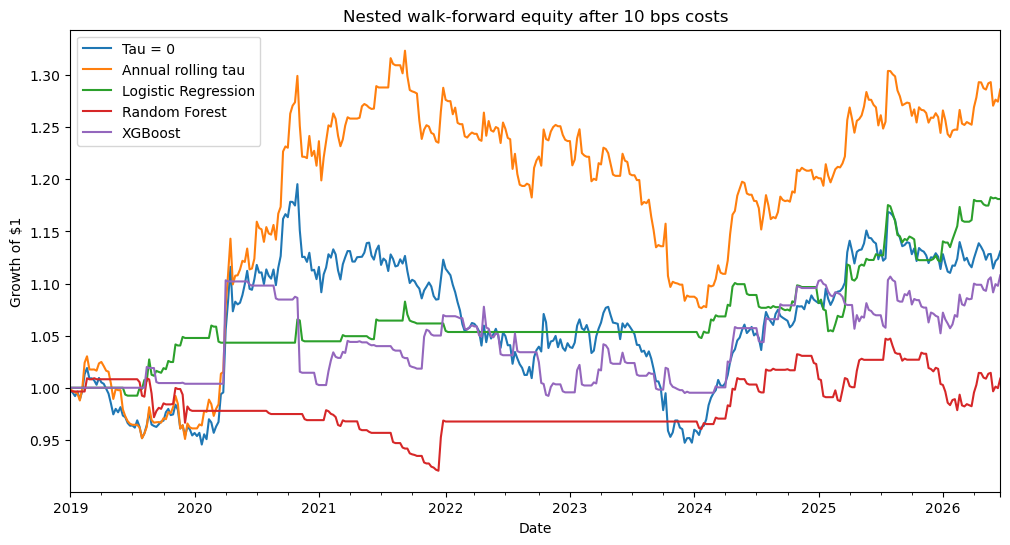

In [54]:
# Stitch each strategy's yearly position chunks into one 2019 -> 2026 timeline
wf_combined_positions = {
    strategy_name: pd.concat(position_parts).sort_index()
    for strategy_name, position_parts in wf_outer_position_parts.items()
}

wf_combined_results = {}
wf_comparison_rows = []

for strategy_name, strategy_positions in wf_combined_positions.items():
    strategy_result = backtest_positions(
        strategy_positions,
        wf_forward_returns.loc[strategy_positions.index],
        initial_capital=I,
        cost_bps=bps,
    )
    wf_combined_results[strategy_name] = strategy_result

    wf_comparison_rows.append(
        {
            "strategy": strategy_name,
            "return_pct": strategy_result["stats"]["total_return"] * 100,
            "sharpe": strategy_result["stats"]["sharpe"],
            "max_drawdown_pct": (
                strategy_result["stats"]["max_drawdown"] * 100
            ),
            "average_gross_exposure": (
                strategy_positions.abs().sum(axis=1).mean()
            ),
            "turnover": strategy_result["stats"]["total_turnover"],
            "active_weeks": int(
                strategy_positions.abs().sum(axis=1).gt(0).sum()
            ),
        }
    )

wf_walk_forward_comparison = pd.DataFrame(wf_comparison_rows)
display(wf_walk_forward_comparison)

plt.figure(figsize=(12, 6))

for strategy_name, strategy_result in wf_combined_results.items():
    (strategy_result["equity"] / I).plot(label=strategy_name)

plt.title("Nested walk-forward equity after 10 bps costs")
plt.ylabel("Growth of $1")
plt.legend()
plt.show()
